Zertifikatstudium: geoDataScience
gds050-01a: Ausgewählte Aspekte des Geoinformationswesens (S) (060884)
WiSe 25/26

Topic: Smart SH Emergency

Author: Justin Lingg-Lahaam
27.02.2026

# UG1: Training and Application Notebook: Model Training, Apply and Export

This notebook trains the U-net-like convolutional neural network (CNN) on the patch dataset generated in Notebook 01 (basement) and applies the trained model to the UG1 study area. The workflow covers loading training patches (`X`, `y`) and normalization parameters, defining (or loading) model architecture, training the model (or loading pre-trained model if available), and running patch-wise inference on UG1 input rasters to produce a spatially continuous `water-depth prediction map`.

The UG1 application step reads the required raster inputs (e.g., DEM, synthetic precipitation, Manning roughness coefficient, and infiltration), ensures consistent grid alignment, normalizes the inputs using the training statistics, and predicts water depth per pixel via tiled patch inference. The final prediction is reassembled to the original raster extent and exported as a georeferenced GeoTIFF for visualization and comparison.

**Outputs**
- `models/final_unet_model_*.keras` (Trained Model)
- `models` (index or metadata of extracted patches)
- `patches/reference_profile.json` (the georeferencing profile for later exports)

In [1]:
# Packages: used Packages and Bibliographies
import os
import glob, random
import numpy as np
import tensorflow as tf
import rasterio
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from keras.models import load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr, spearmanr
from matplotlib.colors import ListedColormap, BoundaryNorm

2026-03-07 15:53:11.449527: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# U-Net-like model tranining (with Load/resume if it is already trained + Checkpoints)

# storage paths  
MODEL_DIR = "models" 
os.makedirs(MODEL_DIR, exist_ok=True)

FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_unet_model_1_80.keras")
NORM_PATH        = os.path.join(MODEL_DIR, "norm_params_u1.npz")

CKPT_LAST = os.path.join(MODEL_DIR, "ckpt_last.keras")  # every epoche, resume if training is canceled 
CKPT_BEST = os.path.join(MODEL_DIR, "ckpt_best.keras")  # best val_loss Modell

# U-net + loss (See GitHub how this works)
##function: builds modellarchitecture (pixel-to-pixel regression for water depth)
def simple_unet(input_shape=(64,64,4)):
    from tensorflow.keras import layers, models
    inputs = layers.Input(shape=input_shape)
    c1 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs) #encoder
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(p1) #encoder (extract features an spatial "press")
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    b = layers.Conv2D(128, (3,3), activation="relu", padding="same")(p2) # compromized representation
    b = layers.BatchNormalization()(b) # stabilized the training

    u1 = layers.UpSampling2D((2,2))(b) # decoder
    u1 = layers.Concatenate()([u1, c2]) # skip-connection (concatenate) which gives the decoder the small details
    c3 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(u1)
    c3 = layers.BatchNormalization()(c3)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(u2)
    c4 = layers.BatchNormalization()(c4)

    outputs = layers.Conv2D(1, (1,1), activation="linear")(c4)
    return models.Model(inputs, outputs)

## Function: loss-function (errors in wet areas are punished more severly then in dry areas) )
def weighted_mse(y_true, y_pred):
    mask = tf.cast(y_true > 0, tf.float32)
    weights = 1.0 + 9.0 * mask
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))


# Case: If Modell exists - load it instead of train it again

if os.path.exists(FINAL_MODEL_PATH) and os.path.exists(NORM_PATH):
    print(f"Model found!: {FINAL_MODEL_PATH} -> reload instead of retrain model")
    model = tf.keras.models.load_model(FINAL_MODEL_PATH, custom_objects={"weighted_mse": weighted_mse})

    norm = np.load(NORM_PATH)
    means = norm["means"].tolist()
    stds  = norm["stds"].tolist()
    y_max = float(norm["y_max"])
    print("Normalisation loaded:", NORM_PATH)

else:
    print("No Model found. Training starts with checkpoints.")

    # calculate normalization out of training
    means = [X[..., c].mean() for c in range(X.shape[-1])]
    stds  = [X[..., c].std()  for c in range(X.shape[-1])]
    y_max = float(y.max())

    X_norm = np.zeros_like(X, dtype="float32")
    for c in range(4):
        if stds[c] > 1e-6:
            X_norm[..., c] = (X[..., c] - means[c]) / stds[c]
        else:
            X_norm[..., c] = 0.0

    y_scaled = (y / y_max).astype("float32")
# split in 80% training, 20% vaildation
    X_train, X_val, y_train, y_val = train_test_split(
        X_norm, y_scaled, test_size=0.2, random_state=42
    )

    #  resume training if checkpoint, if not build new model
    if os.path.exists(CKPT_LAST):
        print(f"Resume: load last Checkpoint: {CKPT_LAST}")
        model = tf.keras.models.load_model(CKPT_LAST, custom_objects={"weighted_mse": weighted_mse})
    else:
        model = simple_unet()

    # (Re-)compile (safety)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss=weighted_mse)

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1
    )

    cb_last = ModelCheckpoint(
        filepath=CKPT_LAST,
        save_best_only=False,   # always save
        save_freq="epoch",
        verbose=1
    )

    cb_best = ModelCheckpoint(
        filepath=CKPT_BEST,
        monitor="val_loss",
        save_best_only=True,    # only when better
        verbose=1
    )

    history = model.fit(
        X_train, y_train[..., np.newaxis],
        validation_data=(X_val, y_val[..., np.newaxis]),
        batch_size=16,
        epochs=50,
        verbose=1,
        callbacks=[reduce_lr, cb_last, cb_best]
    )

    # final save
    model.save(FINAL_MODEL_PATH)
    np.savez(NORM_PATH, means=np.array(means, dtype="float32"),
                      stds=np.array(stds, dtype="float32"),
                      y_max=np.array(y_max, dtype="float32"))

    print(f"Finished model saved : {FINAL_MODEL_PATH}")
    print(f"Normalisation saved: {NORM_PATH}")


✅ Modell gefunden: models/final_unet_model_1_80.keras -> lade statt neu zu trainieren
✅ Normalisierung geladen: models/norm_params_u1.npz


2026-03-07 15:53:13.709765: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# Application of the trained Model

# UG1 Parameter
PATH_DEM = "input/DEM.tif" # DEM
PATH_RAIN = "simulation/pos_synth_2_80_infil.tif" # positive excess rainfall
PATH_MANNING = "input/mkoeff_UG.tif" # Manning coefficient
INFILTRATION_WERT = 2.78e-6 # Infiltrationrate                                   
PATH_OUTPUT = "ug1/pred/predicted_depth_1_80_ug1.tif"
PATH_MODEL  = "models/final_unet_model_1_80.keras"
PATH_NORM   = "models/norm_params_u1.npz"                        

PATCH_SIZE = 64
STRIDE     = 32
BATCH_SIZE = 16



# helper: read raster (GeoTIFF)
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        nodata = src.nodata
    return arr, profile, nodata

# helper: bring raster on same grid as DEM (same resolution, source, projection)
def read_and_match_to_ref(path, ref_profile, resampling=Resampling.bilinear):
    with rasterio.open(path) as src:
        src_arr = src.read(1).astype("float32")
        src_nodata = src.nodata
        dst_arr = np.empty((ref_profile["height"], ref_profile["width"]), dtype="float32")

        reproject(
            source=src_arr,
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=resampling,
            src_nodata=src_nodata,
            dst_nodata=src_nodata,
        )
    return dst_arr, src_nodata

# Function: cleans Inputs to be "safe" (no NoData, no extremes)
def clean_raster(arr, nodata=None, fill_value=0.0):
    a = arr.astype("float32", copy=False)
    invalid = ~np.isfinite(a)
    if nodata is not None and np.isfinite(nodata):
        invalid |= (a == np.float32(nodata))
    invalid |= (np.abs(a) > 1e10)
    out = a.copy()
    out[invalid] = np.float32(fill_value)
    return out, invalid

# Function: normalization like training, but robust
def safe_norm(x, mean, std):
    if float(std) > 1e-6:
        return (x - mean) / std
    return np.zeros_like(x, dtype="float32")

# Function: Makes a prediction map out of a Rasterstack (H,W,4)
def predict_whole_map_from_stack(model, stack, patch_size=64, stride=32, batch_size=16):
    H, W, C = stack.shape
    pred_map = np.zeros((H, W), dtype="float32")
    counts   = np.zeros((H, W), dtype="float32")

    patches, coords = [], []

    def flush():
        nonlocal patches, coords, pred_map, counts
        if not patches:
            return
        batch = np.stack(patches, axis=0).astype("float32")
        y = model.predict(batch, verbose=0)
        if y.ndim == 4:
            y = y[..., 0]
        y = y.astype("float32")
        for k, (i, j) in enumerate(coords):
            pred_map[i:i+patch_size, j:j+patch_size] += y[k]
            counts[i:i+patch_size, j:j+patch_size] += 1.0
        patches.clear()
        coords.clear()

    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patches.append(stack[i:i+patch_size, j:j+patch_size, :])
            coords.append((i, j))
            if len(patches) >= batch_size:
                flush()
    flush()

    counts[counts == 0] = 1.0
    return (pred_map / counts).astype("float32")


# Run the Model (Must be the same pre-processing steps as in training to use the right scale)

# load Modell + Normalization
model = tf.keras.models.load_model(PATH_MODEL, custom_objects={"weighted_mse": weighted_mse})
norm = np.load(PATH_NORM)
means = norm["means"].astype("float32")  # 4 Values
stds  = norm["stds"].astype("float32")   # 4 Values
y_max = float(norm["y_max"])

print("means:", means)
print("stds :", stds)
print("y_max:", y_max)

# DEM as Referencegrid
dem, profile_dem, dem_nodata = read_raster(PATH_DEM)

# parameter on DEM-grid
rain, rain_nodata = read_and_match_to_ref(PATH_RAIN,    profile_dem, resampling=Resampling.bilinear)
mann, mann_nodata = read_and_match_to_ref(PATH_MANNING, profile_dem, resampling=Resampling.bilinear)
infil = (INFILTRATION_WERT * np.ones_like(dem, dtype="float32"))

# cleaning: Norm on invalid places = 0 (fill=mean)
dem_c,  m_dem  = clean_raster(dem,  dem_nodata,  fill_value=float(means[0]))
rain_c, m_rain = clean_raster(rain, rain_nodata, fill_value=float(means[1]))
mann_c, m_mann = clean_raster(mann, mann_nodata, fill_value=float(means[2]))
infil_c,m_inf  = clean_raster(infil, None,       fill_value=float(means[3]))

invalid = m_dem | m_rain | m_mann | m_inf

# Norm as in Training
stack_norm = np.stack([
    safe_norm(dem_c,   means[0], stds[0]),
    safe_norm(rain_c,  means[1], stds[1]),
    safe_norm(mann_c,  means[2], stds[2]),
    safe_norm(infil_c, means[3], stds[3]),
], axis=-1).astype("float32")

# Predict (y_scaled)
pred_scaled = predict_whole_map_from_stack(
    model, stack_norm,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    batch_size=BATCH_SIZE
)

# Downscale (Meter)
pred = (pred_scaled * y_max).astype("float32")

# invalid unmask
pred = pred.copy()
pred[invalid] = np.nan

# clip
pred = np.clip(pred, 0.0, 5.0).astype("float32")

# save
os.makedirs(os.path.dirname(PATH_OUTPUT), exist_ok=True)
out_profile = profile_dem.copy()
out_profile.update(dtype="float32", count=1, nodata=np.nan, compress="lzw")

with rasterio.open(PATH_OUTPUT, "w", **out_profile) as dst:
    dst.write(pred, 1)

print("saved:", PATH_OUTPUT)


means: [9.3839073e+00 7.5779867e+00 1.2162895e-01 2.7799999e-06]
stds : [ 5.340079   17.364       0.10997979  0.        ]
y_max: 40.17326736450195
✅ gespeichert: ug1/pred/predicted_depth_1_80_ug1.tif


In [7]:
# Evaluation-Block: show prediction vs. reference

#Function: read raster and reference data
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        prof = src.profile.copy()
        nodata = src.nodata
        transform = src.transform
    return arr, prof, nodata, transform

# Function: bring raster to Grid of prediction
def align_to_ref(path, ref_profile, ref_transform, ref_crs, resampling, dst_nodata=np.nan):
    with rasterio.open(path) as src:
        src_arr = src.read(1).astype("float32")
        out = np.full((ref_profile["height"], ref_profile["width"]), dst_nodata, dtype="float32")

        reproject(
            source=src_arr,
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=resampling,
            src_nodata=src.nodata,
            dst_nodata=dst_nodata
        )
    return out

#Function: calculate pixel-area in m2 
def pixel_area_from_transform(transform):
    # transform.a = pixel width, transform.e = pixel height (often negative)
    return float(abs(transform.a * transform.e))

# Masking 

# Function: defines which pixel may be included in the evaluation
def valid_mask(pred, ref, pred_nodata=None, ref_nodata=None, max_depth_m=10.0):
    m = np.isfinite(pred) & np.isfinite(ref)

    if pred_nodata is not None and np.isfinite(pred_nodata):
        m &= (pred != np.float32(pred_nodata))
    if ref_nodata is not None and np.isfinite(ref_nodata):
        m &= (ref != np.float32(ref_nodata))

    # plausibility filter (important against outliner/scale errors)
    m &= (pred >= 0) & (pred <= max_depth_m)
    m &= (ref  >= 0) & (ref  <= max_depth_m)

    return m

# Metrics
#Function: Regression quality for continuous water depth.
def regression_metrics(pred, ref):
    diff = pred - ref
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae  = float(np.mean(np.abs(diff)))
    bias = float(np.mean(diff))
    pr   = float(pearsonr(pred, ref)[0]) if pred.size > 2 else np.nan
    sr   = float(spearmanr(pred, ref)[0]) if pred.size > 2 else np.nan
    return {"RMSE": rmse, "MAE": mae, "Bias": bias, "Pearson": pr, "Spearman": sr}

 # Function: converts depths to Flood/NoFlood using threshold  
def classification_metrics(pred, ref, thr=0.01): # Threshold 0.01 m = 1 cm
    pred_f = pred > thr
    ref_f  = ref  > thr

    TP = int(np.sum(pred_f & ref_f))
    FP = int(np.sum(pred_f & (~ref_f)))
    FN = int(np.sum((~pred_f) & ref_f))
    TN = int(np.sum((~pred_f) & (~ref_f)))

    acc = (TP + TN) / max(TP + TN + FP + FN, 1)
    prec = TP / max(TP + FP, 1)
    rec  = TP / max(TP + FN, 1)
    f1   = (2*prec*rec) / max(prec + rec, 1e-12)
    iou  = TP / max(TP + FP + FN, 1)

    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Accuracy": float(acc),
        "Precision": float(prec),
        "Recall": float(rec),
        "F1": float(f1),
        "IoU": float(iou)
    }

#Function: calculates spatial metrics
def spatial_metrics(pred, ref, pixel_area, thr=0.01):
    pred_f = pred > thr
    ref_f  = ref  > thr

    area_pred = float(np.sum(pred_f) * pixel_area)
    area_ref  = float(np.sum(ref_f)  * pixel_area)
    area_intersection = float(np.sum(pred_f & ref_f) * pixel_area)

    vol_pred = float(np.sum(pred[pred_f] * pixel_area))
    vol_ref  = float(np.sum(ref[ref_f]  * pixel_area))

    return {
        "Area_pred_m2": area_pred,
        "Area_ref_m2": area_ref,
        "Area_intersection_m2": area_intersection,
        "Area_diff_m2": float(area_pred - area_ref),
        "Vol_pred_m3": vol_pred,
        "Vol_ref_m3": vol_ref,
        "Vol_diff_m3": float(vol_pred - vol_ref),
    }


# Calibration: (Post-Hoc) 

#Function: preparation for QM-Mapping: so that it does not crash later
def _safe_interp_setup(x, y):

    x = np.asarray(x, dtype="float32")
    y = np.asarray(y, dtype="float32")
    xs, idx = np.unique(x, return_index=True)
    ys = y[idx]
    if xs.size < 2:
        xs = np.array([0.0, 1.0], dtype="float32")
        ys = np.array([ys[0] if ys.size else 0.0, ys[0] if ys.size else 0.0], dtype="float32")
    return xs, ys

# Function: learns Quantile.Mapping-Calibration out of Cal event
def fit_quantile_calibrator(pred_path, ref_path, max_depth_m=10.0, n_q=2000, ref_is_categorical=False):
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)

    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )

    m = valid_mask(pred, ref, pred_nod, None, max_depth_m=max_depth_m)
    if int(np.sum(m)) == 0:
        raise ValueError("No valid pixels for calibration.")

    p = pred[m].ravel()
    r = ref[m].ravel()

    qs = np.linspace(0, 1, int(n_q))
    pred_q = np.quantile(p, qs).astype("float32")
    ref_q  = np.quantile(r, qs).astype("float32")

    pred_q_u, ref_q_u = _safe_interp_setup(pred_q, ref_q)
    return {"type": "QM", "pred_q": pred_q_u, "ref_q": ref_q_u, "max_depth_m": float(max_depth_m)}

# Function: uses QM for whole map
def apply_quantile_calibrator(pred_map, calib):
    flat = pred_map.ravel().astype("float32")
    out = flat.copy()
    m = np.isfinite(out)
    out[m] = np.interp(out[m], calib["pred_q"], calib["ref_q"]).astype("float32")
    out = np.clip(out, 0, calib["max_depth_m"])
    return out.reshape(pred_map.shape).astype("float32")

# Function: learn linear mapping (as a comparison to QM)
def fit_linear_calibrator(pred_path, ref_path, max_depth_m=10.0, ref_is_categorical=False):
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)

    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )

    m = valid_mask(pred, ref, pred_nod, None, max_depth_m=max_depth_m)
    if int(np.sum(m)) == 0:
        raise ValueError("No valid pixels for calibration.")

    p = pred[m].ravel().astype("float64")
    r = ref[m].ravel().astype("float64")

    A = np.vstack([p, np.ones_like(p)]).T
    a, b = np.linalg.lstsq(A, r, rcond=None)[0]
    return {"type": "LIN", "a": float(a), "b": float(b), "max_depth_m": float(max_depth_m)}
# Functzion: uses linear mapping
def apply_linear_calibrator(pred_map, calib):
    out = calib["a"] * pred_map + calib["b"]
    out = np.clip(out, 0, calib["max_depth_m"])
    return out.astype("float32")


# Function: uses evaluation for the UG1
def evaluate_event(pred_path, ref_path, thr=0.01, max_depth_m=10.0, ref_is_categorical=False, calibrator=None):
    # pred is reference grid
    pred, pred_prof, pred_nod, pred_transform = read_raster(pred_path)
    pixel_area = pixel_area_from_transform(pred_transform)

    # align ref to pred grid
    resamp = Resampling.nearest if ref_is_categorical else Resampling.bilinear
    ref = align_to_ref(
        ref_path,
        ref_profile=pred_prof,
        ref_transform=pred_transform,
        ref_crs=pred_prof["crs"],
        resampling=resamp,
        dst_nodata=np.nan
    )

    # apply calibration (post-hoc) 
    method = "RAW"
    pred_used = pred
    if calibrator is not None:
        method = f"CAL_{calibrator.get('type', 'UNK')}"
        if calibrator.get("type") == "QM":
            pred_used = apply_quantile_calibrator(pred, calibrator)
        elif calibrator.get("type") == "LIN":
            pred_used = apply_linear_calibrator(pred, calibrator)
        else:
            raise ValueError(f"Unknown calibrator type: {calibrator.get('type')}")

    m = valid_mask(pred_used, ref, pred_nod, None, max_depth_m=max_depth_m)
    n = int(np.sum(m))

    if n == 0:
        return {"n_valid": 0, "error": "No valid pixels after masking.", "method": method}

    p = pred_used[m].ravel()
    r = ref[m].ravel()

    out = {
        "n_valid": n,
        "pred_path": pred_path,
        "ref_path": ref_path,
        "thr_m": thr,
        "max_depth_m": max_depth_m,
        "method": method
    }
    out.update(regression_metrics(p, r))
    out.update(classification_metrics(p, r, thr=thr))
    out.update(spatial_metrics(p, r, pixel_area=pixel_area, thr=thr))
    return out



In [8]:
# Define a Event (UG1)
events = [
  {
    "name": "UG1_1_80",
    "pred": "ug1/pred/predicted_depth_1_80_ug1.tif",   #adjust if new Preciptation or other places should be used
    "ref":  "simulation/synth_water_depth_2_80_pos"         
  }
]
res = evaluate_event(events[0]["pred"], events[0]["ref"], thr=0.01, max_depth_m=10.0)

# calibration on UG1
calib_event = events[0]  # z.B. UG2_1_80
cal_qm = fit_quantile_calibrator(
    calib_event["pred"], calib_event["ref"],
    max_depth_m=10.0, n_q=2000
)
# optional linear:
# cal_lin = fit_linear_calibrator(calib_event["pred"], calib_event["ref"], max_depth_m=10.0)

# evaluation table
results = []
for e in events:
    # RAW
    r_raw = evaluate_event(e["pred"], e["ref"], thr=0.01, max_depth_m=10.0)
    r_raw["event"] = e["name"]
    results.append(r_raw)

    # CAL_QM
    r_cal = evaluate_event(e["pred"], e["ref"], thr=0.01, max_depth_m=10.0, calibrator=cal_qm)
    r_cal["event"] = e["name"]
    results.append(r_cal)

df = pd.DataFrame(results)
df


,n_valid,pred_path,ref_path,thr_m,max_depth_m,method,RMSE,MAE,Bias,Pearson,...,F1,IoU,Area_pred_m2,Area_ref_m2,Area_intersection_m2,Area_diff_m2,Vol_pred_m3,Vol_ref_m3,Vol_diff_m3,event
0,1998434,ug1/pred/predicted_depth_1_80_ug1.tif,simulation/synth_water_depth_2_80_pos,0.01,10.0,RAW,0.056999,0.019646,-0.001188,0.636482,...,0.605501,0.434207,491437.0,277846.0,232901.0,213591.0,34291.601562,38720.839844,-4429.238281,UG1_1_80
1,1998434,ug1/pred/predicted_depth_1_80_ug1.tif,simulation/synth_water_depth_2_80_pos,0.01,10.0,CAL_QM,0.066512,0.018559,0.000098,0.601586,...,0.577405,0.405882,277840.0,277846.0,160428.0,-6.0,38917.398438,38720.839844,196.558594,UG1_1_80


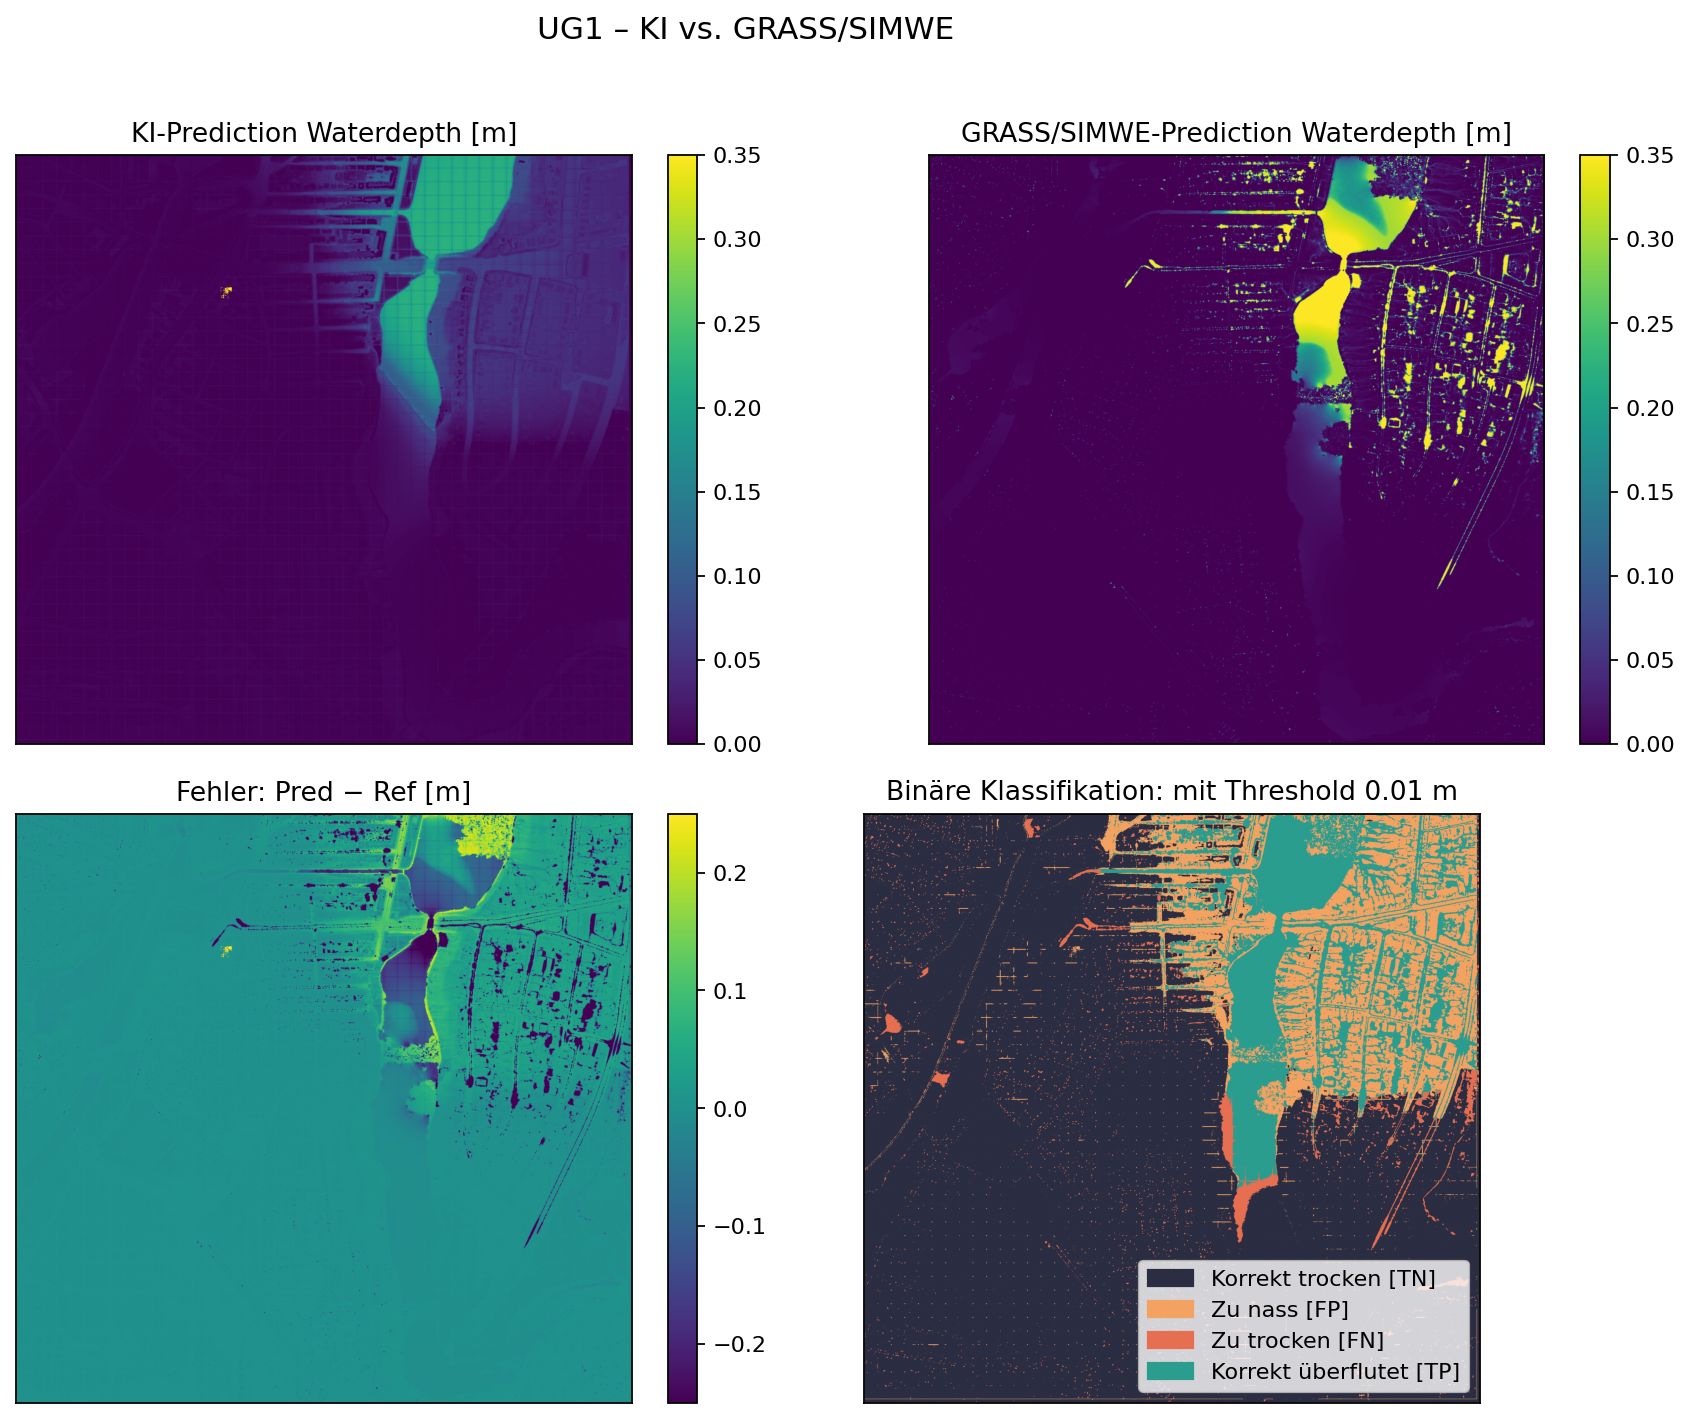

In [10]:
# Visualization-Block

# Function: read path and reproject/resample to ghe Grid of the Reference
def read_match_to_ref(src_path, ref_ds, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        src_arr = src.read(1).astype("float32")
        dst_arr = np.empty((ref_ds.height, ref_ds.width), dtype="float32")
        reproject(
            source=src_arr,
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_ds.transform,
            dst_crs=ref_ds.crs,
            resampling=resampling
        )
        return dst_arr

# Function: build mask of plausble pixel
def get_valid_mask(pred, ref, pred_nodata=None, ref_nodata=None, clip_min=0.0, clip_max=10.0):
    m = np.isfinite(pred) & np.isfinite(ref)
    if pred_nodata is not None:
        m &= (pred != pred_nodata)
    if ref_nodata is not None:
        m &= (ref != ref_nodata)
    if clip_min is not None:
        m &= (pred >= clip_min) & (ref >= clip_min)
    if clip_max is not None:
        m &= (pred <= clip_max) & (ref <= clip_max)
    return m

# Function: build a plot with 4 maps
def plot_ug_panel(pred_path, ref_path, thr=0.01, max_depth=0.35, vmax_err=0.25, out_png=None):
    # Open reference (grid template)
    with rasterio.open(ref_path) as ref_ds:
        ref = ref_ds.read(1).astype("float32")
        ref_nodata = ref_ds.nodata

        # Read+match prediction onto ref grid
        pred = read_match_to_ref(pred_path, ref_ds, resampling=Resampling.bilinear)

    # If pred file has a nodata value, read it
    with rasterio.open(pred_path) as pds:
        pred_nodata = pds.nodata

    # Mask + clip to range for fair plotting
    valid = get_valid_mask(pred, ref, pred_nodata=pred_nodata, ref_nodata=ref_nodata, clip_min=0.0, clip_max=10.0)

    pred_v = np.where(valid, pred, np.nan)
    ref_v  = np.where(valid, ref,  np.nan)
    err    = pred_v - ref_v

    # Confusion map for flood/not-flood at threshold
    pred_f = pred_v >= thr
    ref_f  = ref_v  >= thr

    # Codes: 0 TN, 1 FP, 2 FN, 3 TP
    conf = np.zeros(pred_v.shape, dtype="uint8")
    conf[(~pred_f) & (~ref_f) & valid] = 0
    conf[( pred_f) & (~ref_f) & valid] = 1
    conf[(~pred_f) & ( ref_f) & valid] = 2
    conf[( pred_f) & ( ref_f) & valid] = 3
    conf[~valid] = 255  # invalid

    # Colormap
    cmap = ListedColormap(["#2b2d42", "#f4a261", "#e76f51", "#2a9d8f"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, axs = plt.subplots(2, 2, figsize=(12, 9), dpi=160)

    im0 = axs[0,0].imshow(pred_v, vmin=0, vmax=max_depth)
    axs[0,0].set_title("KI-Prediction Waterdepth [m]")
    plt.colorbar(im0, ax=axs[0,0], fraction=0.046, pad=0.04)

    im1 = axs[0,1].imshow(ref_v, vmin=0, vmax=max_depth)
    axs[0,1].set_title("GRASS/SIMWE-Prediction Waterdepth [m]")
    plt.colorbar(im1, ax=axs[0,1], fraction=0.046, pad=0.04)

    im2 = axs[1,0].imshow(err, vmin=-vmax_err, vmax=vmax_err)
    axs[1,0].set_title("Fehler: Pred − Ref [m]")
    plt.colorbar(im2, ax=axs[1,0], fraction=0.046, pad=0.04)

    # Confusion plot: mask invalid as transparent
    conf_plot = conf.astype("float32")
    conf_plot[conf_plot == 255] = np.nan
    im3 = axs[1,1].imshow(conf_plot, cmap=cmap, norm=norm)
    axs[1,1].set_title(f"Binäre Klassifikation: mit Threshold {thr:.2f} m")

    # legend (for lecture)
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color=cmap.colors[0], label="Korrekt trocken [TN]"),
        mpatches.Patch(color=cmap.colors[1], label="Zu nass [FP]"),
        mpatches.Patch(color=cmap.colors[2], label="Zu trocken [FN]"),
        mpatches.Patch(color=cmap.colors[3], label="Korrekt überflutet [TP]"),
    ]
    axs[1,1].legend(handles=legend_patches, loc="lower right", frameon=True)

    for ax in axs.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle("UG1 – KI vs. GRASS/SIMWE", y=0.98, fontsize=14)
    fig.tight_layout(rect=[0,0,1,0.96])

    if out_png:
        plt.savefig(out_png, bbox_inches="tight")
    plt.show()

# example call
pred_path = "predicted_depth_2_80.tif"
ref_path  = "simulation/synth_water_depth_2_80_pos" 
plot_ug_panel(pred_path, ref_path, thr=0.01, max_depth=0.35, vmax_err=0.25, out_png="ug1/UG1_panel.png")
